# Case 9

# How does the adaptive threshold's EMA smoothing rate affect LSTM-VAE on group anomalies?

## Purpose of this notebook

This notebook demonstrates the effect of one of the rolling-threshold machanisms:

> The adaptive decision threshold is not recalibrated instantly — it tracks the live anomaly-score distribution via an exponential moving average (EMA). The EMA smoothing factor controls how quickly that threshold responds: `ema=0.0` freezes it at its warmup-calibrated value (no online recalibration at all), while higher values let it track the live distribution more aggressively.

The thesis studies anomaly detection in streaming ERA5 weather data. It compares the impact of different configurations (VAE architecture, streaming and feature manipulation methods, threshold adaptation rate) on VAEs with different deep learning models as encoder/decoder.

This testcase focuses on **group anomalies** (collective mean-shift blocks) and **LSTM-VAE only**, evaluated at five EMA values.

The group anomalies dataset used is a comparatively easy scenario for the feed-forward models: MLP-VAE and MLP-VAE-Cyclic can detect the mean shift directly from the current window, without needing any recurrence or attention over the sequence, so threshold-adaptation rate is not where their behaviour is most interesting to study on this anomaly type. LSTM-VAE, whose scores are shaped by its recurrent state, is where the thesis found threshold-adaptation rate actually matters for this anomaly type — so this notebook isolates LSTM-VAE to show that sensitivity directly.

---
For the complete experiment definitions, consult the thesis section associated with **4.4.4 Effects of Rolling Prediction Threshold Tuning** (Table 4.18, Figure 4.17), together with the YAML configuration files used by this suite.

## What is being compared?

The notebook runs five LSTM-VAE variants, identical except for the threshold's EMA smoothing factor:

| Variant | EMA | Meaning |
|---|---:|---|
| **LSTM-VAE** | 0.0 | Threshold frozen at its warmup-calibrated value — no online recalibration. |
| **LSTM-VAE** | 0.05 | Very slow adaptation. |
| **LSTM-VAE** | 0.2 | Default adaptation rate. |
| **LSTM-VAE** | 0.5 | Fast adaptation. |
| **LSTM-VAE** | 0.8 | Very fast adaptation — the threshold tracks the live score distribution closely. |

An EMA of 0 is a special case: the threshold never updates after warmup, so the whole test stream is evaluated against one fixed decision boundary.

## Findings being illustrated

The thesis found that LSTM-VAE's detection performance on group anomalies changes with the threshold's adaptation rate — unlike MLP-VAE and MLP-VAE-Cyclic, whose group-anomaly detection depends much less on how the threshold adapts, since a mean-shift block is visible directly in the current window regardless of what came before. LSTM-VAE's anomaly scores are shaped by its recurrent hidden state, which continues to evolve. This notebook simulates how quickly the threshold tracks that evolving score distribution.

This reduced notebook uses the full-scale ERA5 export by default (see `case01_clean_baseline.ipynb` for why), so results should be directionally close to the thesis, though exact metric values are not expected to match (single seed, this repo's own port of the training code). The important result is **whether F1 changes meaningfully across the EMA sweep**, not a single best value — the thesis's finding is about sensitivity, not that any one EMA is universally correct.

---

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run the five EMA variants on the same group-anomaly dataset.
4. Collect F1, AUC, precision, recall, and confusion-matrix counts.
5. Plot F1 across the EMA sweep, and threshold behaviour across the stream.

### Expected runtime

Window-based runs use the GPU when available. All five variants share the same architecture (LSTM-VAE) and dataset, so runtimes should be similar across variants.

### Before running

This notebook reads code and data from a **private GitHub repository**. You must:

1. Have permission to access the read-only repository with a fine-grained GitHub token.
2. In Colab, open the **Secrets** panel using the key icon.
3. Add the secret `GITHUB_TOKEN`.
4. Enable **Notebook access** for that secret.
5. Select **Runtime → Change runtime type → GPU**.
6. Choose **Runtime → Run all**.

The source ERA5 data and its licence information are described in `DATA_LICENSE.md`.

# Run Case

### Check GPU availability

In [3]:
%matplotlib inline
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


Environment check
-----------------
PyTorch version: 2.11.0+cu128
CUDA available: True
Selected device: Tesla T4


### Import and/or load Repo

In [4]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import userdata

    token = userdata.get("GITHUB_TOKEN")
    if not token:
        raise RuntimeError(
            "The Colab secret GITHUB_TOKEN is unavailable. "
            "Open the key icon in the left sidebar, add the token, "
            "and enable Notebook access."
        )

    if not REPO_DIR.exists():
        # Use an askpass helper so the token is not stored in the Git remote URL.
        askpass = Path("/content/git_askpass.sh")
        askpass.write_text(
            '#!/bin/sh\n'
            'case "$1" in\n'
            '  *Username*) echo "x-access-token" ;;\n'
            '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
            'esac\n'
        )
        askpass.chmod(0o700)

        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        env["GIT_ASKPASS"] = str(askpass)
        env["GIT_TERMINAL_PROMPT"] = "0"

        try:
            subprocess.run(
                ["git", "clone", REPO_URL, str(REPO_DIR)],
                check=True,
                env=env,
            )
        finally:
            askpass.unlink(missing_ok=True)

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("run_regression.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


Working directory: /content/repo
Installing the project dependencies...
env: MPLBACKEND=Agg
Setup complete.


### Step 1 — Configure the run

In [5]:
import os
import yaml

CASE_ID = "case09_ema_freezing"
SESSION_DIR = "runs/regression"
OUTPUT_DIR = f"{SESSION_DIR}/{CASE_ID}"

# Edit this directly — works the same locally and on Colab:
#   "full_split_files" (default) -> anom_types/group.yaml's own default —
#                      full-scale group-anomaly data, pre-split into a
#                      warmup-only file (shared with case01 — the warmup
#                      portion is anomaly-free and identical regardless of
#                      anomaly type) and a test-only file with the
#                      group anomalies injected. Committed to the repo.
#   "mini_50pct"    -> the in-repo 377,784-row ERA5 slice (~50% of full-scale).
#                      Committed to the repo.
#   "mini_28pct"    -> the in-repo 210,384-row ERA5 slice (~28% of full-scale).
#                      Committed to the repo.
DATA_SOURCE = "full_split_files"

_DATA_SOURCE_LAYERS = {
    "full_split_files": None,   # anom_types/group.yaml's own default — no extra layer needed
    "mini_50pct": "../../modules/data_source/mini_50pct_group.yaml",
    "mini_28pct": "../../modules/data_source/mini_28pct_group.yaml",
}

_suite_source_path = f"notebooks/cases/{CASE_ID}_suite.yaml"
_suite_dir = os.path.dirname(os.path.abspath(_suite_source_path))

def _resolve(path):
    # base_config / config_layers entries are relative paths meant to be
    # read relative to the suite file's own directory (notebooks/cases/).
    # Resolving them to absolute paths here — rather than leaving them
    # relative — means the resolved copy stays correct no matter how deep
    # under OUTPUT_DIR it ends up being written.
    return path if os.path.isabs(path) else os.path.normpath(os.path.join(_suite_dir, path))

_data_source_layer = _DATA_SOURCE_LAYERS[DATA_SOURCE]

with open(_suite_source_path) as f:
    _suite = yaml.safe_load(f)

_suite["base_config"] = _resolve(_suite["base_config"])
for _run in _suite["runs"]:
    _layers = [_resolve(p) for p in _run["config_layers"]]
    if _data_source_layer:
        _layers.append(_resolve(_data_source_layer))
    _run["config_layers"] = _layers

# Written under OUTPUT_DIR (runs/, already gitignored and read-write) rather
# than notebooks/ (source-controlled, meant to stay read-only) — os.makedirs
# because OUTPUT_DIR won't exist yet on a fresh run.
os.makedirs(OUTPUT_DIR, exist_ok=True)
SUITE_PATH = f"{OUTPUT_DIR}/{CASE_ID}_suite_resolved.yaml"
with open(SUITE_PATH, "w") as f:
    yaml.safe_dump(_suite, f, sort_keys=False)

print(f"DATA_SOURCE = {DATA_SOURCE!r} -> {_data_source_layer}")

DATA_SOURCE = 'full_split_files' -> None


#### Configuration file

The notebooks test suites combines a shared ERA5 configuration (`modules/era5_common.yaml`) with the architecture, anomaly type, stream mode, and threshold-EMA settings for each run.

`DATA_SOURCE` may be configured to choose other datasets from the era5 data directory.
The default is `"full_split_files"`, which is the full-scale group-anomaly data, where warmup and test files are split (`data/era5/full_scale/split/era5_clean_warmup.csv` and `data/era5/full_scale/split/era5_group_test.csv`).

All variants use the same base configuration, architecture, and evaluation procedure. The intended comparison is therefore the effect of **threshold EMA smoothing rate** on LSTM-VAE's group-anomaly detection.

#### Output Directory

During execution, the script creates a separate run directory in the repo for each variant under `OUTPUT_DIR` (`runs/regression/case09_ema_freezing` by default).

`notebooks/cases/case09_ema_freezing_suite.yaml` layers `modules/era5_common.yaml` with the architecture / anomaly-type / stream-mode fragments and the per-run EMA override (see the suite file for the exact overrides).

### Step 2 Run the testsuite

### Command:

In [10]:
!python run_regression.py {SUITE_PATH} \
    --session {SESSION_DIR} --skip-existing

[suite] log     : /content/repo/runs/regression/suite.log
[suite] suite   : /content/repo/runs/regression/case09_ema_freezing/case09_ema_freezing_suite_resolved.yaml
[suite] session : /content/repo/runs/regression
[suite] base cfg: /content/repo/modules/era5_common.yaml
[suite] module  : regression.run_trial
[suite] GPUs    : [0]  (1 slot(s))
[suite] 5 run(s) planned:
  [  1] LSTM_ema_0_00  [case09_ema_freezing/case09_ema_freezing_suite_resolved]  (module: regression.run_trial)
  [  2] LSTM_ema_0_05  [case09_ema_freezing/case09_ema_freezing_suite_resolved]  (module: regression.run_trial)
  [  3] LSTM_ema_0_2  [case09_ema_freezing/case09_ema_freezing_suite_resolved]  (module: regression.run_trial)
  [  4] LSTM_ema_0_5  [case09_ema_freezing/case09_ema_freezing_suite_resolved]  (module: regression.run_trial)
  [  5] LSTM_ema_0_8  [case09_ema_freezing/case09_ema_freezing_suite_resolved]  (module: regression.run_trial)
[suite] --skip-existing: completed runs will be skipped
[suite] SKIP   '

### Step 3 — Build a common comparison

#### The next command reads the predictions from every run and produces:

- a common performance table
- anomaly-score histograms
- an F1 comparison across variants
- confusion-matrix summaries
- seed-stability diagnostics, where applicable.

These outputs are saved under `OUTPUT_DIR/cross_compare/`.

### Command:

In [11]:
!python cross_compare.py {OUTPUT_DIR}

[cross] session : runs/regression/case09_ema_freezing
[cross] output  : runs/regression/case09_ema_freezing/cross_compare
[cross] 5 run(s) found:
  LSTM_Group_0.0                                      arch=LSTM  anomaly=Group  cyclic=False  mode=window
  LSTM_Group_0.05                                     arch=LSTM  anomaly=Group  cyclic=False  mode=window
  LSTM_Group_0.2                                      arch=LSTM  anomaly=Group  cyclic=False  mode=window
  LSTM_Group_0.5                                      arch=LSTM  anomaly=Group  cyclic=False  mode=window
  LSTM_Group_0.8                                      arch=LSTM  anomaly=Group  cyclic=False  mode=window

[cross] Loading run data ...
  LSTM_Group_0.0 ... ok
  LSTM_Group_0.05 ... ok
  LSTM_Group_0.2 ... ok
  LSTM_Group_0.5 ... ok
  LSTM_Group_0.8 ... ok

[cross] Writing outputs ...
  saved performance_table.csv
  saved performance_summary.txt

  ══ Group anomalies ════════════════════════════════════════════════════════════

### Step 4 — Quantitative Results

### Command:

In [12]:
import pandas as pd
from IPython.display import display

performance_path = f"{OUTPUT_DIR}/cross_compare/performance_table.csv"
perf = pd.read_csv(performance_path)

columns = [
    "run_name", "arch", "anomaly", "variant",
    "f1", "auc", "precision", "recall",
    "tp", "fp", "fn",
]

perf["variant"] = perf["variant"].astype(float)

print("Comparison of EMA variants")
display(
    perf[columns]
    .sort_values("variant")
    .reset_index(drop=True)
    .style.format({
        "f1": "{:.3f}",
        "auc": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
    })
)

Comparison of EMA variants


,run_name,arch,anomaly,variant,f1,auc,precision,recall,tp,fp,fn
0,LSTM_Group_0.0,LSTM,Group,0.000000,0.609,0.899,0.447,0.957,3759,4656,171
1,LSTM_Group_0.05,LSTM,Group,0.050000,0.745,0.933,0.620,0.934,3669,2247,261
2,LSTM_Group_0.2,LSTM,Group,0.200000,0.675,0.899,0.591,0.787,3094,2144,836
3,LSTM_Group_0.5,LSTM,Group,0.500000,0.800,0.951,0.702,0.929,3653,1554,277
4,LSTM_Group_0.8,LSTM,Group,0.800000,0.802,0.950,0.703,0.934,3669,1549,261


#### Expected pattern

```text
LSTM-VAE: F1 varies noticeably across ema = 0.0 / 0.05 / 0.2 / 0.5 / 0.8
```

The testcase is successful when F1 shows a clear, non-flat trend across the EMA sweep, even if the exact values or the direction of the trend differ from the thesis — the point being demonstrated is sensitivity to adaptation rate, not a single best EMA value.

### Step 5 — Qualitative support (Plots)

#### F1, recall, and precision by EMA value

##### Command:

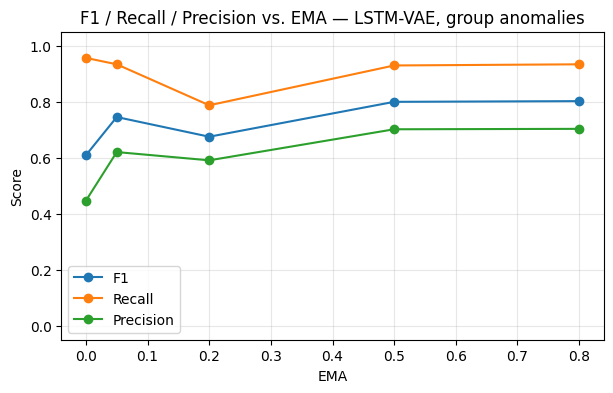

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

performance_path = f"{OUTPUT_DIR}/cross_compare/performance_table.csv"
perf = pd.read_csv(performance_path)
perf["variant"] = perf["variant"].astype(float)
perf = perf.sort_values("variant")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(perf["variant"], perf["f1"], marker="o", label="F1")
ax.plot(perf["variant"], perf["recall"], marker="o", label="Recall")
ax.plot(perf["variant"], perf["precision"], marker="o", label="Precision")
ax.set_xlabel("EMA")
ax.set_ylabel("Score")
ax.set_title("F1 / Recall / Precision vs. EMA — LSTM-VAE, group anomalies")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()
display(fig)
plt.close(fig)

F1, recall, and precision plotted together against EMA, read directly from the performance table above.

#### The plots and numeric results indicate, among other things:

1. Whether `ema=0.0` (frozen threshold) performs differently from the adaptive settings
2. Whether faster adaptation (`ema=0.5`, `ema=0.8`) tracks group anomalies more or less effectively than the default (`ema=0.2`).
3. Whether F1 changes smoothly across the EMA sweep or has a clear turning point.

### Main takeaway

How quickly the adaptive threshold tracks the live score distribution is not a detail that only matters for architectures with unstable calibration — it can matter even for a recurrent architecture on a comparatively easy anomaly type. LSTM-VAE's scores are shaped by its evolving hidden state rather than the current window in isolation, so how fast the threshold follows that evolving distribution changes whether group anomalies stay detectable as the stream progresses.

## Scope of this testcase

This notebook is a compact demonstration, not a full reproduction of every rolling-threshold experiment reported in the thesis. With `DATA_SOURCE = "full_split_files"` (the default) it runs on the full-scale group-anomaly data. With `DATA_SOURCE = "mini_50pct"` / `"mini_28pct"` a shorter ERA5 interval is used instead — useful for a quick check, but see `case01_clean_baseline.ipynb` for why it can give different results than the full-scale data.

This notebook only tests LSTM-VAE. MLP-VAE and MLP-VAE-Cyclic are excluded deliberately: the thesis found both are comparatively strong and stable on group anomalies regardless of threshold-adaptation rate, since a mean-shift block is visible directly in the current window without needing recurrence or attention over the sequence — so EMA sensitivity is not where their behaviour is most informative on this anomaly type.

Conclusions should be based on the **direction and consistency of the F1-vs-EMA trend**, rather than exact numerical agreement with the thesis figures.
